In [2]:
from zipfile import ZipFile

!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

with ZipFile('10_food_classes_10_percent.zip') as zip:
  zip.extractall()

--2026-03-15 05:48:02--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.163.207, 142.251.167.207, 142.251.179.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.163.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip’

10_food_classes_10_ 100%[===================>] 160.74M   170MB/s    in 0.9s    

2026-03-15 05:48:03 (170 MB/s) - ‘10_food_classes_10_percent.zip’ saved [168546183/168546183]



In [3]:
training_set_dir = '10_food_classes_10_percent/train/'

test_set_dir = '10_food_classes_10_percent/test/'

In [5]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [6]:
# Pembuatan Training Set
training_set = image_dataset_from_directory(
  directory = training_set_dir,
  image_size = (224,224),
  label_mode = 'categorical',
  batch_size = 32,
  validation_split = 0.3,
  subset = 'training',          #bernilai ’training’
  seed = 42)

# Pembuatan Validation Set
validation_set = image_dataset_from_directory(
       directory = training_set_dir, #sama dengan training_set
       image_size = (224,224),
       label_mode = 'categorical',
       batch_size = 32,
       validation_split = 0.3,       #sama dengan training_set
       subset = 'validation',        #bernilai ’validation’
       seed = 42)                    #sama dengan training_set

Found 750 files belonging to 10 classes.
Using 525 files for training.
Found 750 files belonging to 10 classes.
Using 225 files for validation.


In [7]:
test_set = image_dataset_from_directory(
directory = test_set_dir,
image_size = (224,224),
label_mode = 'categorical')

Found 2500 files belonging to 10 classes.


In [8]:
from tensorflow.keras.applications import EfficientNetV2B0

pretrained_model = EfficientNetV2B0(
  weights='imagenet',
  include_top=False,
  pooling='avg')

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
pretrained_model.trainable = False

#Definisikan input layer sesuai atribut data Training Set dan tautkan input layer tersebut pada pre-trained model:

from tensorflow.keras.layers import Input

inputs = Input(shape=(224,224,3), name='input_layer')
# Tautkan Input Layer pada pre-trained model
revised_model_3 = pretrained_model(inputs)

In [10]:
from tensorflow.keras.layers import Dense

outputs = Dense(units=10, activation='softmax',name='output_layer')(revised_model_3)

In [14]:
from tensorflow.keras import Model

model_3 = Model(inputs, outputs, name='model_3')

In [18]:
model_3.compile(loss='categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

In [19]:
model_3.summary()

Model: "model_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

es_callback = EarlyStopping(monitor='val_loss', patience=5)
mpt_callback= ModelCheckpoint(filepath='best_model_3.keras',
                                save_best_only=True)

In [23]:
model_3.fit(training_set, epochs=100,
        validation_data = validation_set,
        callbacks = [es_callback, mpt_callback])

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step - accuracy: 0.3371 - loss: 2.0281 - val_accuracy: 0.6311 - val_loss: 1.6111
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.7067 - loss: 1.3616 - val_accuracy: 0.7422 - val_loss: 1.1956
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.7886 - loss: 1.0170 - val_accuracy: 0.7733 - val_loss: 0.9920
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.8400 - loss: 0.8097 - val_accuracy: 0.7778 - val_loss: 0.8795
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.8514 - loss: 0.6855 - val_accuracy: 0.7778 - val_loss: 0.8028
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.8819 - loss: 0.6123 - val_accuracy: 0.8133 - val_loss: 0.7478
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.8800 - loss: 0.5483 - val_accuracy: 0.8133 - val_loss: 0.7110
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.9010 - loss: 0.4886 - val_accuracy: 0.8267 - v

In [27]:
from tensorflow.keras.models import load_model

best_model_3 = load_model('best_model_3.keras')

In [29]:
best_model_3.evaluate(test_set)

79/79 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.8724 - loss: 0.4149


[0.41487744450569153, 0.8723999857902527]

In [30]:
pretrained_model.trainable = True

In [31]:
for urutan, lapisan in enumerate(pretrained_model.layers[:-5]):
  lapisan.trainable = False

In [32]:
revised_model_2 = pretrained_model(inputs)
outputs = Dense(units=10, activation='softmax',
name='output_layer')(revised_model_2)

In [33]:
model_2 = Model(inputs, outputs, name='model_2')

In [35]:
model_2.compile(loss='categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

In [36]:
model_2.summary()

Model: "model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 261,130 (1020.04 KB)

 Non-trainable params: 5,670,992 (21.63 MB)

In [37]:
mpt_callback = ModelCheckpoint(filepath='best_model_2.keras',
                               save_best_only=True)

In [38]:
model_2.fit(training_set, epochs=100,
            validation_data=validation_set,
            callbacks=[es_callback, mpt_callback])

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.5467 - loss: 1.5795 - val_accuracy: 0.7556 - val_loss: 0.9170
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.8400 - loss: 0.6412 - val_accuracy: 0.7822 - val_loss: 0.6682
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.9067 - loss: 0.4149 - val_accuracy: 0.8356 - val_loss: 0.6044
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.9333 - loss: 0.3255 - val_accuracy: 0.8400 - val_loss: 0.5523
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step - accuracy: 0.9714 - loss: 0.2200 - val_accuracy: 0.8356 - val_loss: 0.5439
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.9752 - loss: 0.1728 - val_accuracy: 0.8444 - val_loss: 0.5283
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.9848 - loss: 0.1325 - val_accuracy: 0.8356 - val_loss: 0.5270
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.9886 - loss: 0.1064 - val_accuracy: 0.8444 - v

In [40]:
best_model_2 = load_model('best_model_2.keras')
best_model_2.evaluate(test_set)

79/79 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.8876 - loss: 0.3554


[0.3554362952709198, 0.8876000046730042]

In [41]:
pretrained_model.trainable = True

In [42]:
revised_model_1 = pretrained_model(inputs)
outputs = Dense(units=10, activation='softmax',name='output_layer')(revised_model_1)

In [43]:
model_1 = Model(inputs, outputs, name='model_1')

In [44]:
model_1.compile(loss='categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

In [45]:
model_1.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 261,130 (1020.04 KB)

 Non-trainable params: 5,670,992 (21.63 MB)

In [46]:
mpt_callback = ModelCheckpoint(filepath='best_model_1.keras',save_best_only=True)

In [47]:
model_1.fit(training_set, epochs=100,
            validation_data=validation_set,
            callbacks=[es_callback, mpt_callback])

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.6267 - loss: 1.3802 - val_accuracy: 0.7689 - val_loss: 0.7506
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.8952 - loss: 0.4485 - val_accuracy: 0.8044 - val_loss: 0.5986
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.9600 - loss: 0.2572 - val_accuracy: 0.8267 - val_loss: 0.5591
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step - accuracy: 0.9638 - loss: 0.1926 - val_accuracy: 0.8444 - val_loss: 0.5368
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.9848 - loss: 0.1276 - val_accuracy: 0.8444 - val_loss: 0.5377


In [49]:
best_model_1 = load_model('best_model_1.keras')
best_model_1.evaluate(test_set)

79/79 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.8900 - loss: 0.3618


[0.3618420362472534, 0.8899999856948853]

In [52]:
# Ambil dataset dan unzip data tersebut

!wget https://raw.githubusercontent.com/smirzap/AI-dengan-DL/main/data/my_food_collection.zip

with ZipFile('my_food_collection.zip') as zip:
  zip.extractall()

--2026-03-15 07:29:42--  https://raw.githubusercontent.com/smirzap/AI-dengan-DL/main/data/my_food_collection.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2207554 (2.1M) [application/zip]
Saving to: ‘my_food_collection.zip’

my_food_collection. 100%[===================>]   2.10M  --.-KB/s    in 0.009s  

2026-03-15 07:29:42 (224 MB/s) - ‘my_food_collection.zip’ saved [2207554/2207554]



In [55]:
import os

my_foto = ["my_food_collection/" + foto for foto in os.listdir("my_food_collection")]
my_foto

['my_food_collection/ramen 2.jpeg',
 'my_food_collection/sushi 2.JPG',
 'my_food_collection/beef burger.jpg',
 'my_food_collection/ramen 1.jpeg',
 'my_food_collection/sushi 1.JPG',
 'my_food_collection/sushi 3.jpeg']

In [56]:
best_model_2 = load_model('best_model_2.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


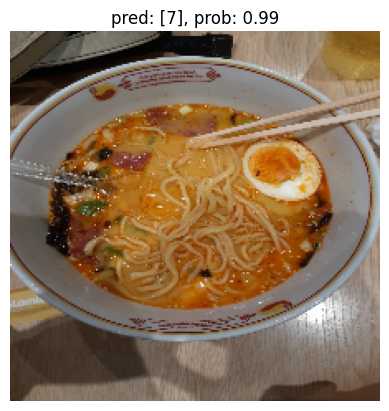

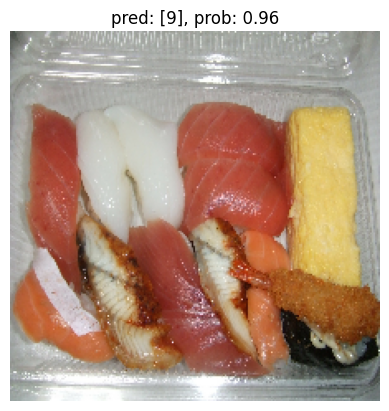

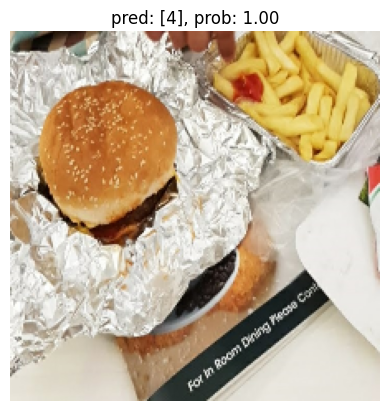

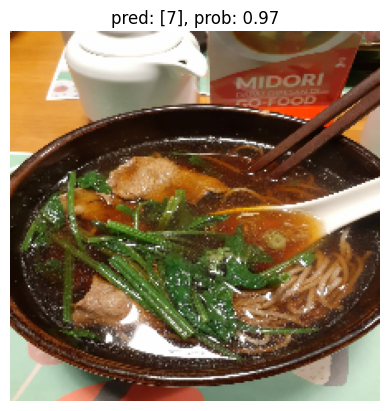

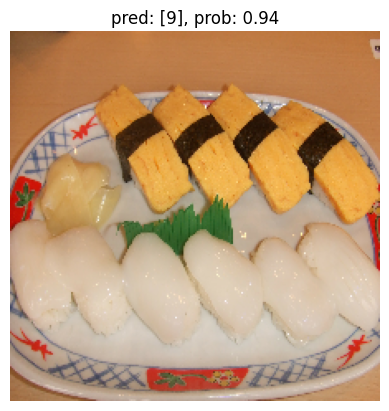

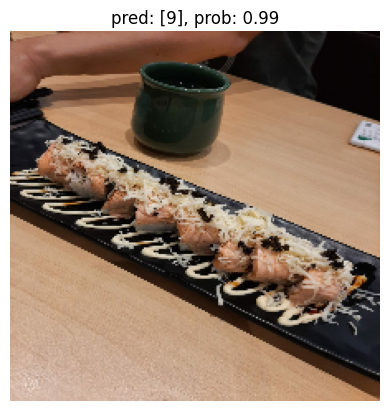

In [58]:
import matplotlib.pyplot as plt
import tensorflow as tf

# Baca satu-persatu file gambar dari list my_foto
for img in my_foto:
  # Baca satu file foto
  img = tf.io.read_file(img)

  # Ubah file foto tersebut kedalam format tensor
  img = tf.io.decode_image(img)

  # Ubah ukuran foto sesuai dengan ukuran gambar model
  img = tf.image.resize(img, [224, 224])

  # Prediksi kategori makanan pada foto
  pred_prob = best_model_2.predict(tf.expand_dims(img, axis=0))

  # Ambil nama kelas yang memiliki nilai kemungkinan terbesar
  pred_catg = pred_prob.argmax(axis=-1)

  # Tayangkan foto berikut hasil prediksi dan nilai kemungkinan
  plt.figure()
  plt.imshow(img/255.)
  plt.title(f"pred: {pred_catg}, prob: {pred_prob.max():.2f}")
  plt.axis(False)